In [ ]:
import pandas as pd

df = pd.read_csv("/Users/minjaekim/Downloads/baby_cries_combined.csv")

In [ ]:
df = df.drop(['Unnamed: 0', 'ParentFile', 'Filename', 'ID', 'Age', 'Gender', 'Date', 'sample'], axis = 1)

There are 3 types of acoustic variables - Loudness, Formants and Others.

### FEATURE ENGINEERING

#### LOUDNESS

In [ ]:
df['loudness_range'] = df['loudness_sma3_percentile80.0'] - df['loudness_sma3_percentile20.0']

df = df.drop(['loudness_sma3_percentile80.0', 'loudness_sma3_percentile20.0'], axis = 1)

#### F0

In [ ]:
df['F0semitoneFrom27.5Hz_range'] = df['F0semitoneFrom27.5Hz_sma3nz_pctlrange0.2']
df = df.drop(['F0semitoneFrom27.5Hz_sma3nz_pctlrange0.2', 'F0semitoneFrom27.5Hz_sma3nz_percentile20.0', 'F0semitoneFrom27.5Hz_sma3nz_percentile80.0'], axis = 1)

In [ ]:
df['F0semitoneFrom27.5Hz_sma3nz_percentile20.0']
df.groupby('Reason')[['F1amplitudeLogRelF0_sma3nz_amean', 'F2amplitudeLogRelF0_sma3nz_amean', 'F3amplitudeLogRelF0_sma3nz_amean']].mean()

,F1amplitudeLogRelF0_sma3nz_amean,F2amplitudeLogRelF0_sma3nz_amean,F3amplitudeLogRelF0_sma3nz_amean
Reason,,,
Diaper-Change,-110.382705,-99.438914,-100.668637
Fussy,-121.883775,-110.498265,-111.557947
Hungry,-103.586669,-91.369059,-92.687857
Pain,-95.743464,-83.827623,-85.599100
Tired,-104.732806,-93.543015,-95.577945


#### Formants

In [ ]:
df['formant_mean'] = df[['F1amplitudeLogRelF0_sma3nz_amean', 'F2amplitudeLogRelF0_sma3nz_amean', 'F3amplitudeLogRelF0_sma3nz_amean']].mean(axis=1)
df = df.drop(['F1amplitudeLogRelF0_sma3nz_amean', 'F2amplitudeLogRelF0_sma3nz_amean', 'F3amplitudeLogRelF0_sma3nz_amean', 'F1amplitudeLogRelF0_sma3nz_stddevNorm', 'F2amplitudeLogRelF0_sma3nz_stddevNorm', 'F3amplitudeLogRelF0_sma3nz_stddevNorm'], axis = 1)

#### Others

####

<Axes: xlabel='HNRdBACF_sma3nz_amean', ylabel='shimmerLocaldB_sma3nz_amean'>

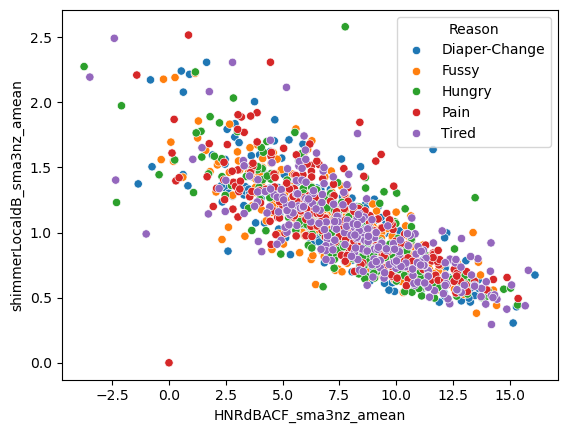

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x = 'HNRdBACF_sma3nz_amean', y = 'shimmerLocaldB_sma3nz_amean', hue = 'Reason', data=df)

<Axes: xlabel='alphaRatioV_sma3nz_amean', ylabel='slopeV500.1500_sma3nz_amean'>

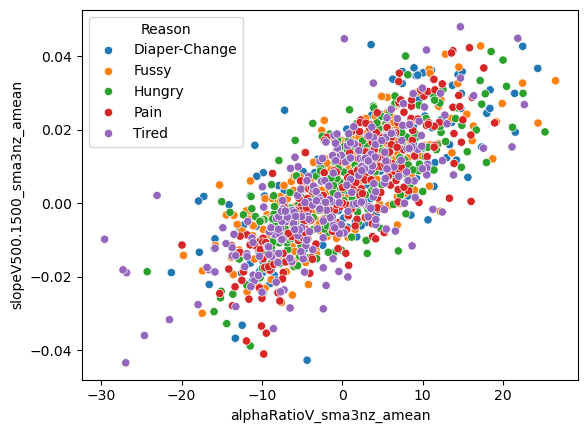

In [ ]:
sns.scatterplot(x = 'alphaRatioV_sma3nz_amean', y = 'slopeV500.1500_sma3nz_amean', hue = 'Reason', data=df)

### DIMENSIONALITY REDUCTION

Dimensionality Reduction techniques that will be used are...
1. Linear Discriminant Analysis
2. Principal Component Analysis
3. UMAP
4. t-SNE

In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

X = df.drop('Reason', axis = 1)
y = df['Reason']

y_encoded = LabelEncoder().fit_transform(y)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#### USING LDA

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
import matplotlib.pyplot as plt
import seaborn as sns


label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

lda = LDA(n_components=None)
X_lda = lda.fit_transform(X_scaled, y_encoded)

print(f"LDA reduced data to {X_lda.shape[1]} dimensions")

LDA reduced data to 4 dimensions (max = n_classes - 1)


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import plotly.express as px

df_LDA = pd.DataFrame({
    'LDA1': X_lda[:, 0],
    'LDA2': X_lda[:, 1],
    'LDA3': X_lda[:, 2],
    'LDA4': X_lda[:, 3],
    'Reason': label_encoder.inverse_transform(y_encoded)

})

fig = px.scatter_3d(
    df_LDA,
    x='LDA1', y='LDA2', z='LDA3',
    color='Reason',
    title='LDA 3D Projection (Interactive)'
)

fig.update_traces(marker=dict(size=5))
fig.show()

For LDA, pain and hungry seem to be linked together, while fussy seems to be on its own.

#### USING PCA FOR DIMENSIONALITY REDUCTION

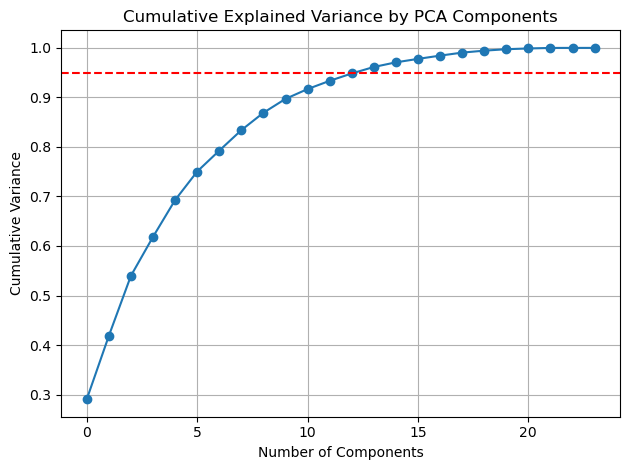

In [ ]:
# optimizing the number of components
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE, Isomap, MDS

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_var_ratio = np.cumsum(pca.explained_variance_ratio_)
optimal_components = np.argmax(explained_var_ratio >= 0.95)

pca_optimal = PCA(n_components=optimal_components)
X_pca_opt = pca_optimal.fit_transform(X_scaled)
plt.plot(explained_var_ratio, marker='o')
plt.axhline(y=0.95, color='r', linestyle='--')
plt.title("Cumulative Explained Variance by PCA Components")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")
plt.grid(True)
plt.tight_layout()
plt.show()


The optimal number of components that explains more than 95% of the variance seems to be 13 components.

#### USING UMAP FOR DIMENSIONALITY REDUCTION

In [ ]:
import umap.umap_ as umap
import hdbscan
import sklearn.cluster as cluster
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score

umap_model = umap.UMAP(n_neighbors = 30, min_dist = 0.0, random_state=42)
X_umap = umap_model.fit_transform(X_scaled)

print(f"UMAP reduced data to {X_umap.shape[1]} dimensions")

/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



UMAP reduced data to 2 dimensions


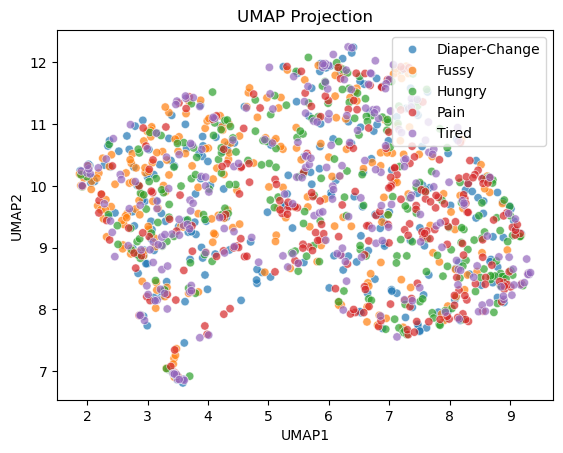

In [ ]:
umap_df = pd.DataFrame({
    'UMAP1': X_umap[:, 0],
    'UMAP2': X_umap[:, 1],
    'Reason': label_encoder.inverse_transform(y_encoded)
})

sns.scatterplot(x='UMAP1', y='UMAP2', hue='Reason', data=umap_df, alpha=0.7)
plt.title("UMAP Projection")
plt.legend(loc ='upper right')

#### USING t-SNE for DIMENSIONALITY REDUCTION

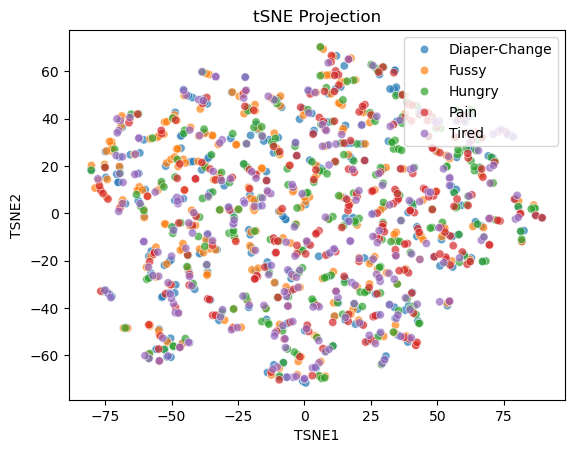

In [ ]:
tsne = TSNE(perplexity=5, learning_rate='auto', random_state=42)
X_tsne_3d = tsne.fit_transform(X_scaled)

# === 4. Create a DataFrame for visualization ===
df_tsne = pd.DataFrame(X_tsne_3d, columns=['TSNE1', 'TSNE2'])
df_tsne['Reason'] = y.values

sns.scatterplot(x='TSNE1', y='TSNE2', hue='Reason', data=df_tsne, alpha=0.7)
plt.title("tSNE Projection")
plt.legend(loc ='upper right')



### Clustering Techniques

For Clustering Techniques, we will use...
1. K-Means Clustering (centroid-based)
2. GMM Clustering (distribution-based)
3. Agglomerative Clustering (hierarchical clustering)
4. DBScan (density-based)

#### K-Means

##### K-Means on LDA

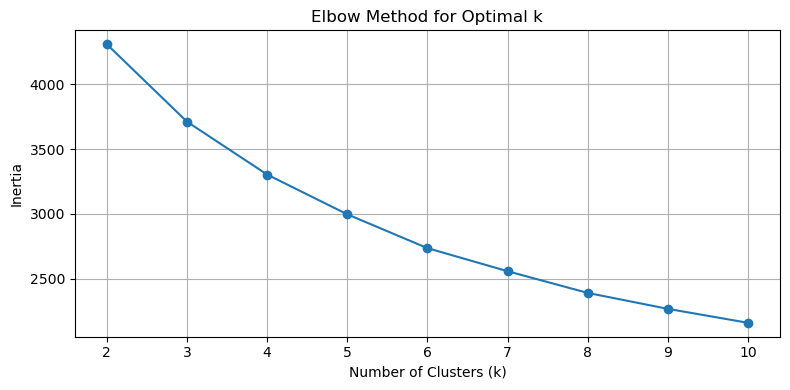

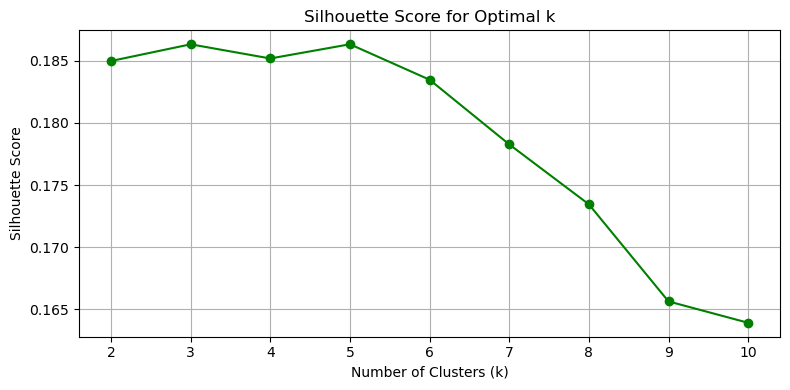

In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = kmeans.fit_predict(X_lda)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_lda, labels))

# Plot Elbow Method
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, marker='o')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot Silhouette Score
plt.figure(figsize=(8, 4))
plt.plot(K_range, silhouettes, marker='o', color='green')
plt.title("Silhouette Score for Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.tight_layout()
plt.show()

kmeans_final = KMeans(n_clusters=2, random_state=42)
cluster_labels = kmeans_final.fit_predict(X_lda)

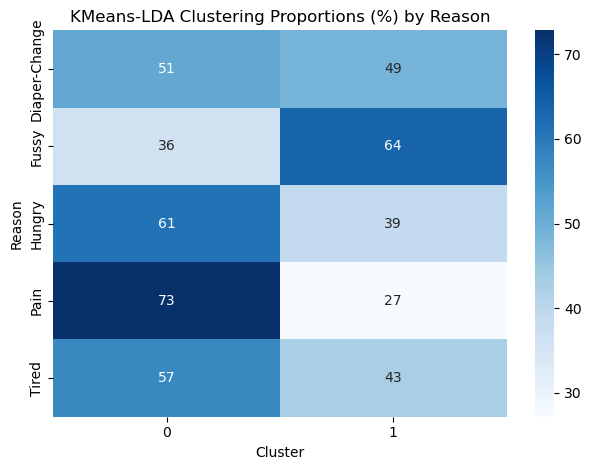

In [ ]:
kmeans_LDA_crosstab = pd.crosstab(index=y, columns=cluster_labels, normalize='index')
kmeans_LDA_proportion_table = kmeans_LDA_crosstab.round(3) * 100
sns.heatmap(kmeans_LDA_proportion_table, annot=True, cmap="Blues")
plt.title("KMeans-LDA Clustering Proportions (%) by Reason")
plt.xlabel("Cluster")
plt.ylabel("Reason")
plt.tight_layout()
plt.show()

##### K-Means on PCA

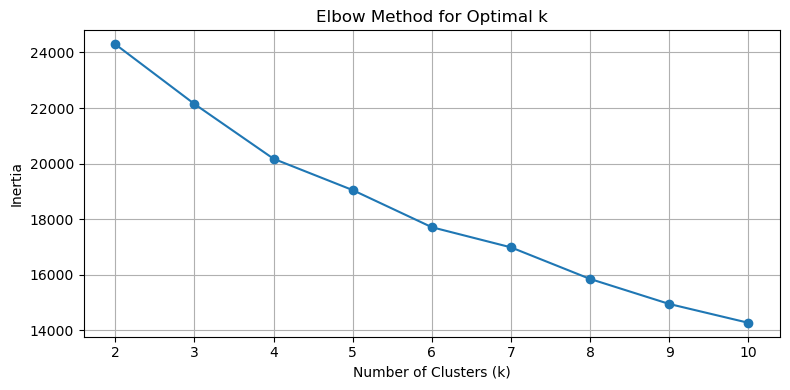

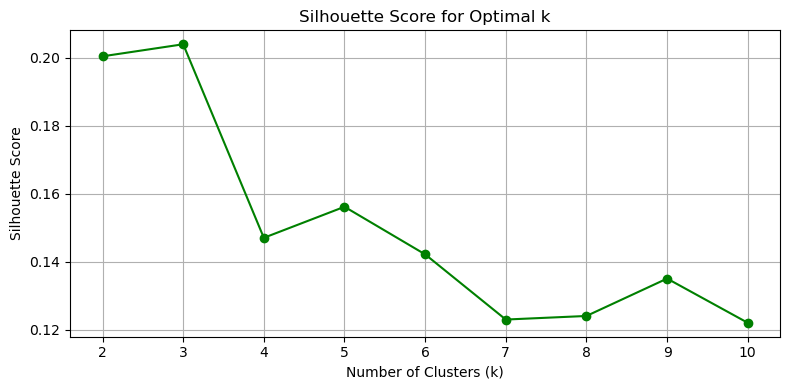

In [ ]:
inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_pca, labels))

# Plot Elbow Method
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, marker='o')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot Silhouette Score
plt.figure(figsize=(8, 4))
plt.plot(K_range, silhouettes, marker='o', color='green')
plt.title("Silhouette Score for Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.tight_layout()
plt.show()

kmeans_final = KMeans(n_clusters=3, random_state=42)
cluster_labels = kmeans_final.fit_predict(X_pca)

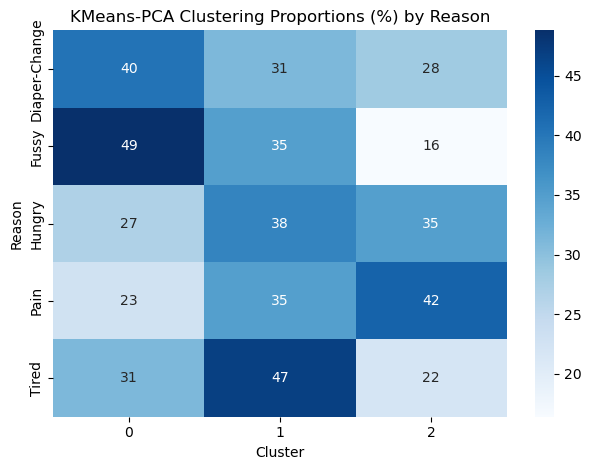

In [ ]:
kmeans_PCA_crosstab = pd.crosstab(index=y, columns=cluster_labels, normalize='index')
kmeans_PCA_proportion_table = kmeans_PCA_crosstab.round(3) * 100
sns.heatmap(kmeans_PCA_proportion_table, annot=True, cmap="Blues")
plt.title("KMeans-PCA Clustering Proportions (%) by Reason")
plt.xlabel("Cluster")
plt.ylabel("Reason")
plt.tight_layout()
plt.show()

##### K-Means on UMAP

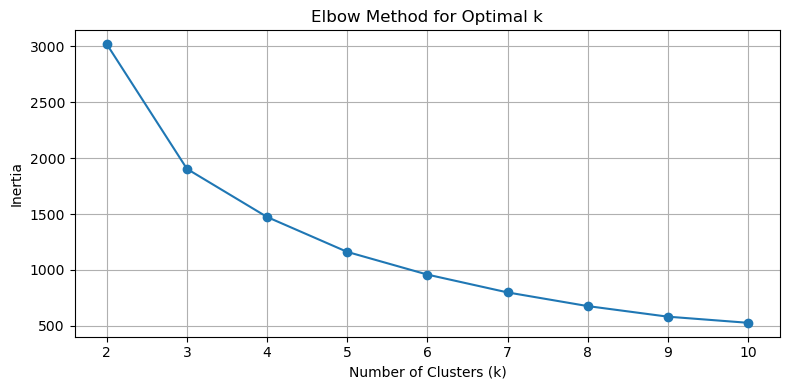

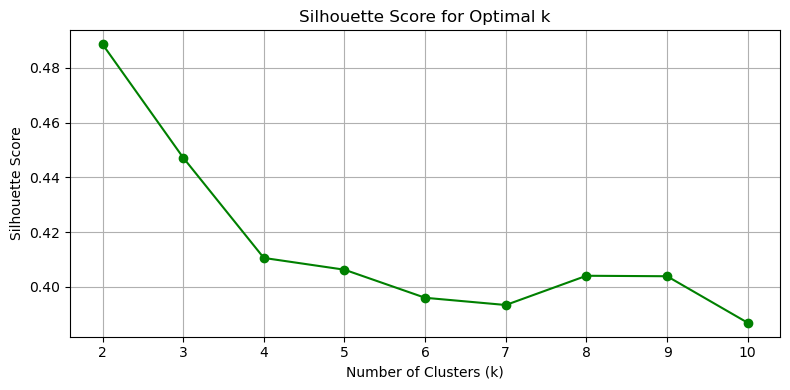

In [ ]:
inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = kmeans.fit_predict(X_umap)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_umap, labels))

# Plot Elbow Method
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, marker='o')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot Silhouette Score
plt.figure(figsize=(8, 4))
plt.plot(K_range, silhouettes, marker='o', color='green')
plt.title("Silhouette Score for Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.tight_layout()
plt.show()

kmeans_final = KMeans(n_clusters=2, random_state=42)
cluster_labels = kmeans_final.fit_predict(X_umap)

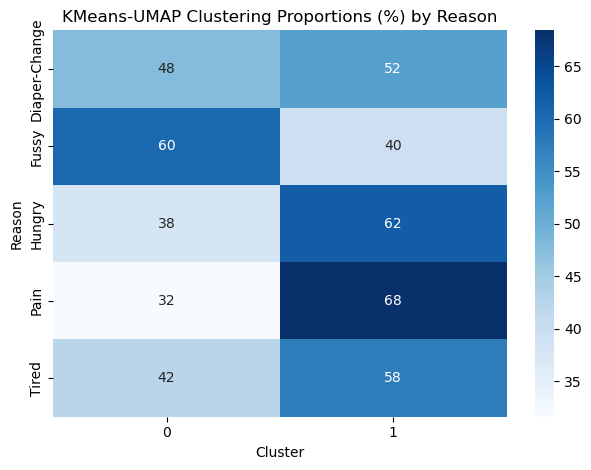

In [ ]:
kmeans_UMAP_crosstab = pd.crosstab(index=y, columns=cluster_labels, normalize='index')
kmeans_UMAP_proportion_table = kmeans_UMAP_crosstab.round(3) * 100
sns.heatmap(kmeans_UMAP_proportion_table, annot=True, cmap="Blues")
plt.title("KMeans-UMAP Clustering Proportions (%) by Reason")
plt.xlabel("Cluster")
plt.ylabel("Reason")
plt.tight_layout()
plt.show()

##### K-Means on t-SNE

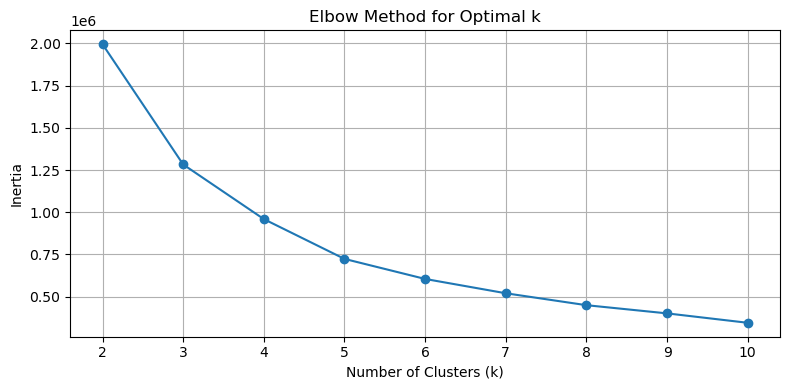

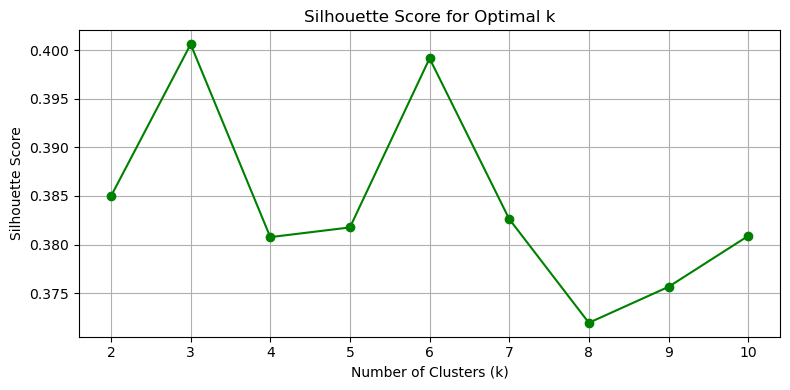

In [ ]:
inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = kmeans.fit_predict(X_tsne_3d)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_tsne_3d, labels))

# Plot Elbow Method
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, marker='o')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot Silhouette Score
plt.figure(figsize=(8, 4))
plt.plot(K_range, silhouettes, marker='o', color='green')
plt.title("Silhouette Score for Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.tight_layout()
plt.show()

kmeans_final = KMeans(n_clusters=3, random_state=42)
cluster_labels = kmeans_final.fit_predict(X_tsne_3d)

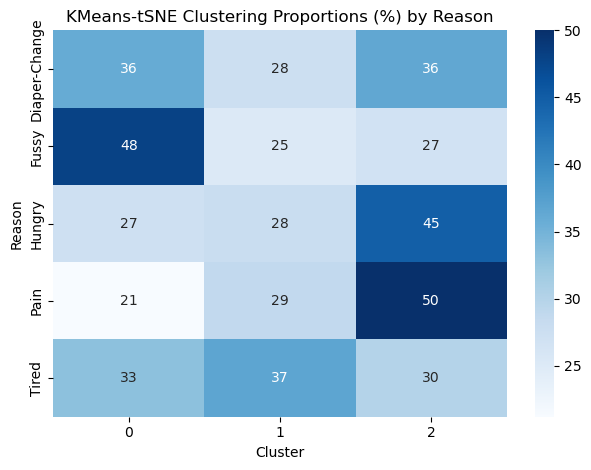

In [ ]:
kmeans_tsne_crosstab = pd.crosstab(index=y, columns=cluster_labels, normalize='index')
kmeans_tsne_proportion_table = kmeans_tsne_crosstab.round(3) * 100
sns.heatmap(kmeans_tsne_proportion_table, annot=True, cmap="Blues")
plt.title("KMeans-tSNE Clustering Proportions (%) by Reason")
plt.xlabel("Cluster")
plt.ylabel("Reason")
plt.tight_layout()
plt.show()

#### GMM Clustering

In [ ]:
distortions = []
for k in range(2, 10):
    kmeans = GaussianMixture(n_components=k, random_state=42)
    kmeans.fit(X_with_gender_age)
    distortions.append(kmeans.inertia_)

plt.plot(range(2, 10), distortions, marker='o')
plt.title('Elbow Method - GMM with Gender and Age')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

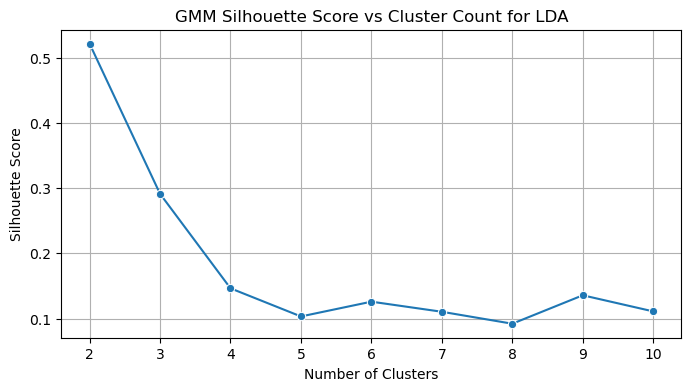

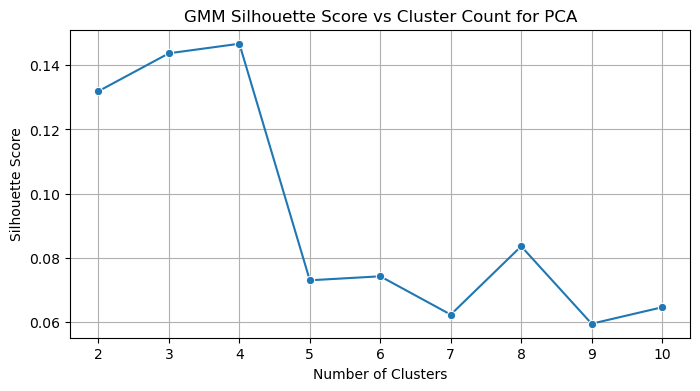

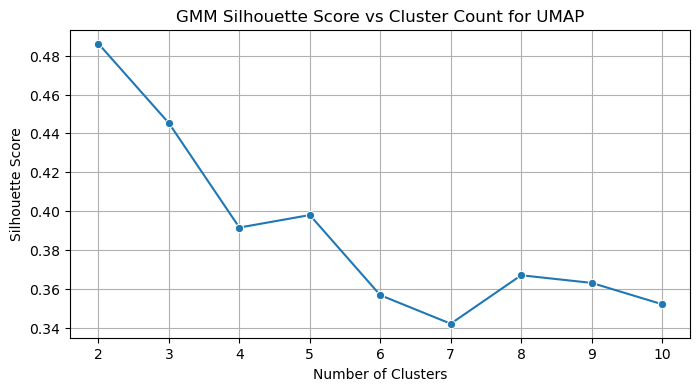

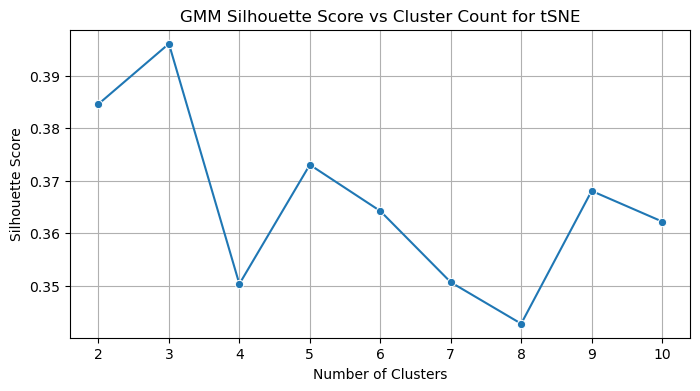

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import numpy as np

datasets = {
    'LDA': X_lda,
    'PCA': X_pca,
    'UMAP': X_umap,
    'tSNE': X_tsne_3d
}

gmm_labels = {}
gmm_scores = {}

for name, data in datasets.items():
    scores = []
    best_score = -1
    best_labels = None

    for n in range(2, 11):
        gmm = GaussianMixture(n_components=n, random_state=42)
        labels = gmm.fit_predict(data)
        if len(np.unique(labels)) > 1:
            score = silhouette_score(data, labels)
            scores.append((n, score))
            if score > best_score:
                best_score = score
                best_labels = labels

    gmm_labels[name] = best_labels
    gmm_scores[name] = scores

    plt.figure(figsize=(8, 4))
    sns.lineplot(x=[x[0] for x in scores], y=[x[1] for x in scores], marker="o")
    plt.title(f'GMM Silhouette Score vs Cluster Count for {name}')
    plt.xlabel('Number of Clusters')
    plt.ylabel('Silhouette Score')
    plt.grid(True)
    plt.show()


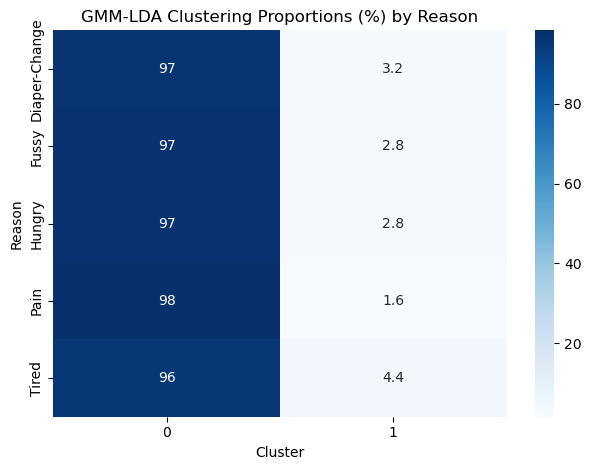

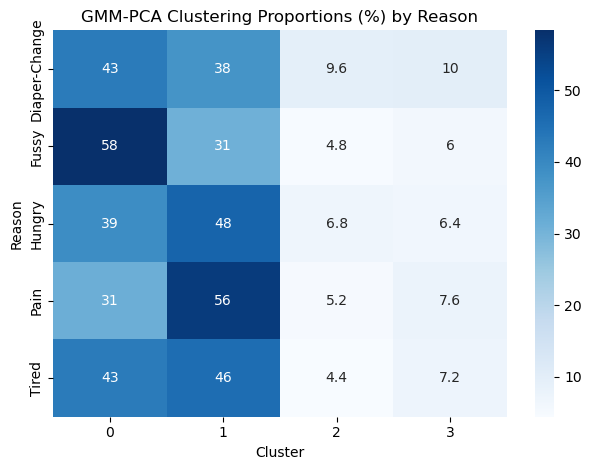

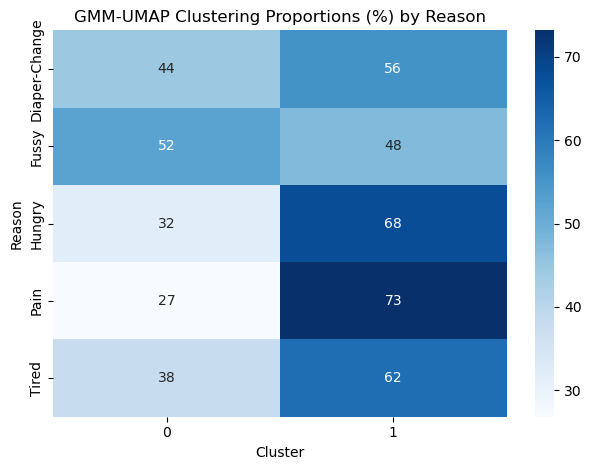

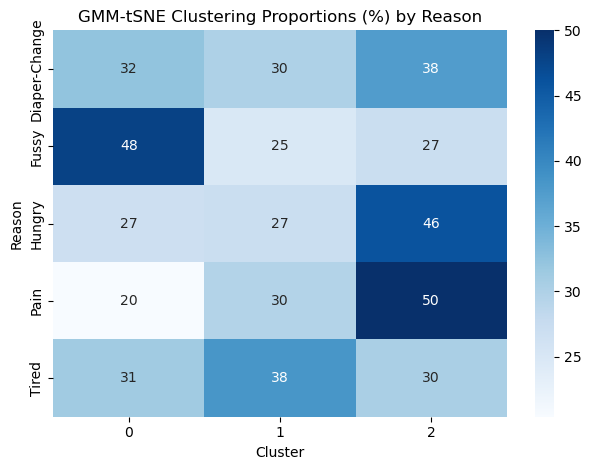

In [ ]:
for name, labels in gmm_labels.items():
    gmm_crosstab = pd.crosstab(index=y, columns=labels, normalize='index')
    gmm_proportion_table = gmm_crosstab.round(3) * 100
    sns.heatmap(gmm_proportion_table, annot=True, cmap="Blues")
    plt.title(f"GMM-{name} Clustering Proportions (%) by Reason")
    plt.xlabel("Cluster")
    plt.ylabel("Reason")
    plt.tight_layout()
    plt.show()

#### Agglomerative Clustering

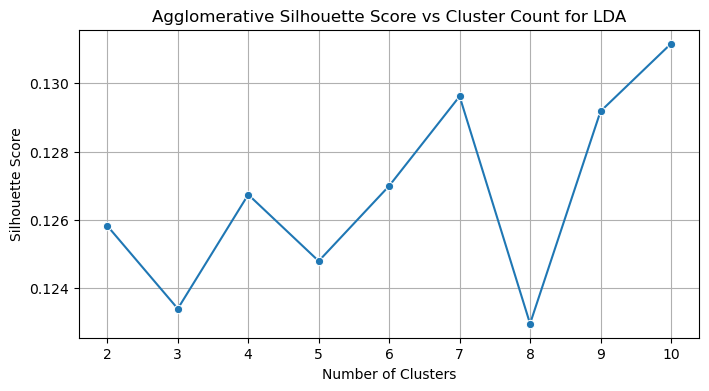

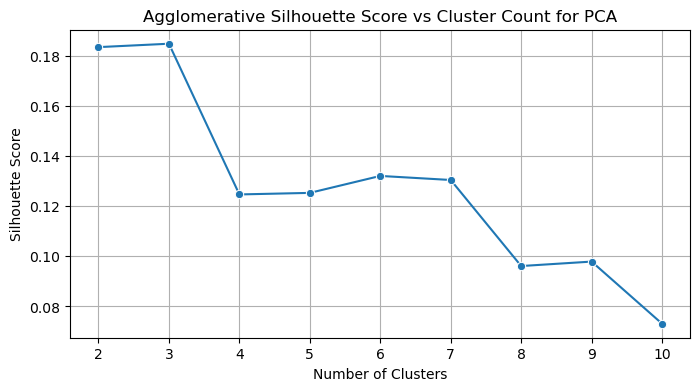

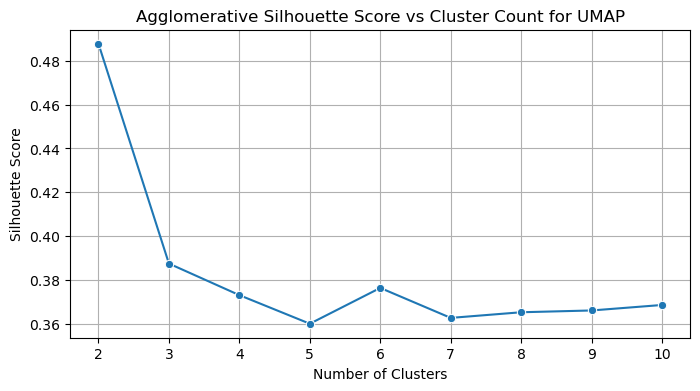

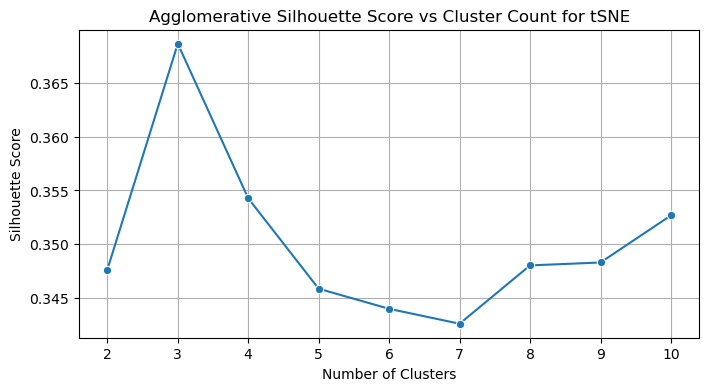

In [ ]:
from sklearn.cluster import AgglomerativeClustering

agglo_labels = {}
agglo_scores = {}

for name, data in datasets.items():
    scores = []
    best_score = -1
    best_labels = None

    for n in range(2, 11):
        model = AgglomerativeClustering(n_clusters=n)
        labels = model.fit_predict(data)
        if len(np.unique(labels)) > 1:
            score = silhouette_score(data, labels)
            scores.append((n, score))
            if score > best_score:
                best_score = score
                best_labels = labels

    agglo_labels[name] = best_labels
    agglo_scores[name] = scores

    # Plot silhouette score
    plt.figure(figsize=(8, 4))
    sns.lineplot(x=[x[0] for x in scores], y=[x[1] for x in scores], marker="o")
    plt.title(f'Agglomerative Silhouette Score vs Cluster Count for {name}')
    plt.xlabel('Number of Clusters')
    plt.ylabel('Silhouette Score')
    plt.grid(True)
    plt.show()


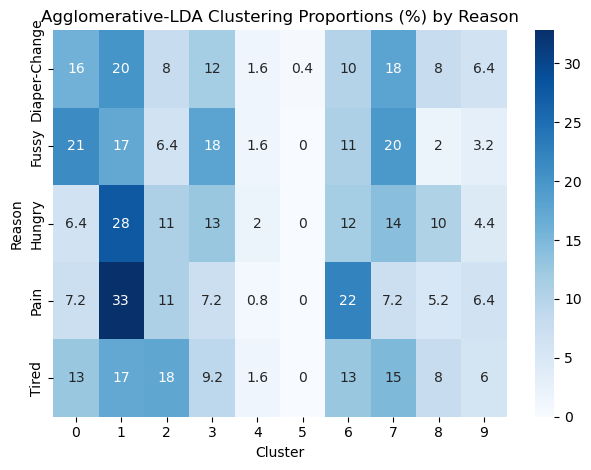

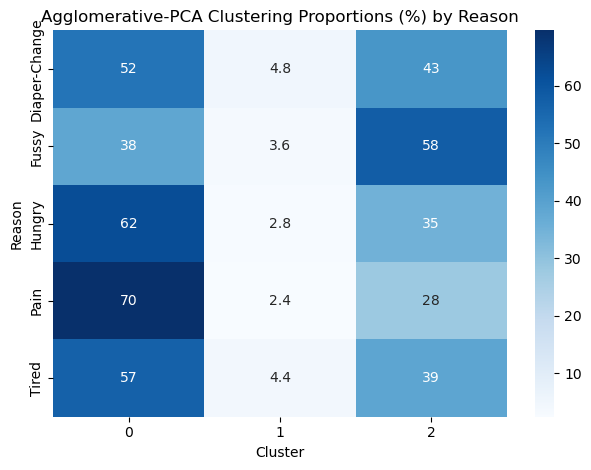

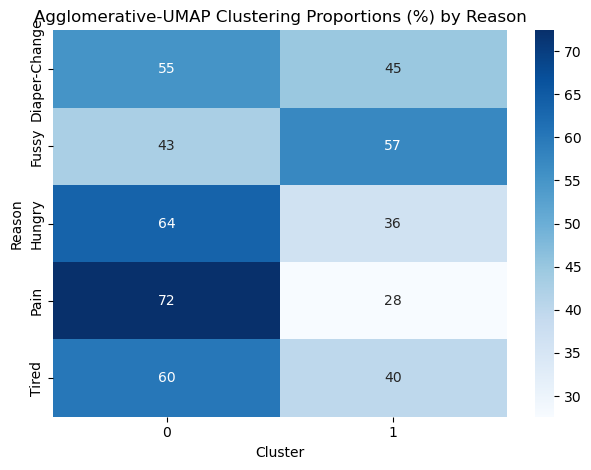

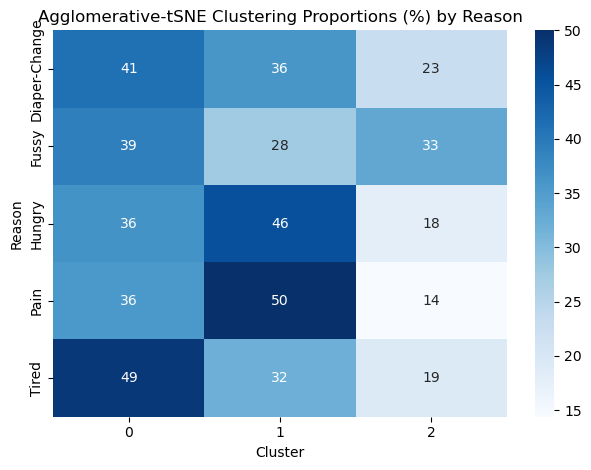

In [ ]:
for name, labels in agglo_labels.items():
    agglo_crosstab = pd.crosstab(index=y, columns=labels, normalize='index')
    agglo_proportion_table = agglo_crosstab.round(3) * 100
    sns.heatmap(agglo_proportion_table, annot=True, cmap="Blues")
    plt.title(f"Agglomerative-{name} Clustering Proportions (%) by Reason")
    plt.xlabel("Cluster")
    plt.ylabel("Reason")
    plt.tight_layout()
    plt.show()

#### DBScan

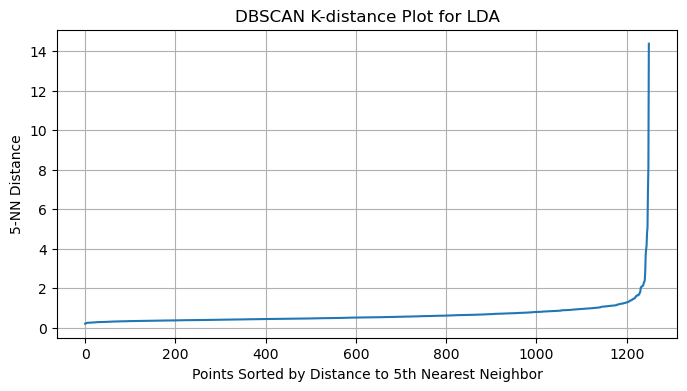

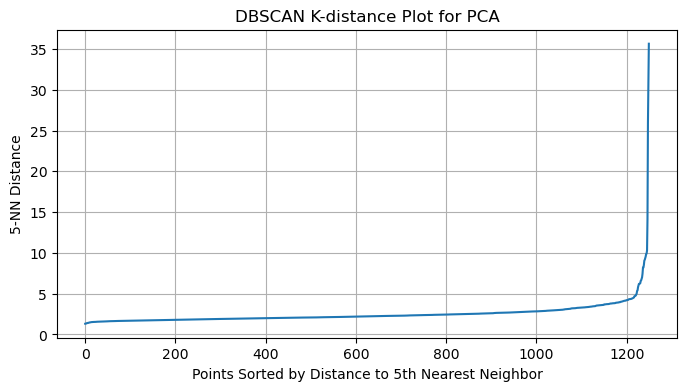

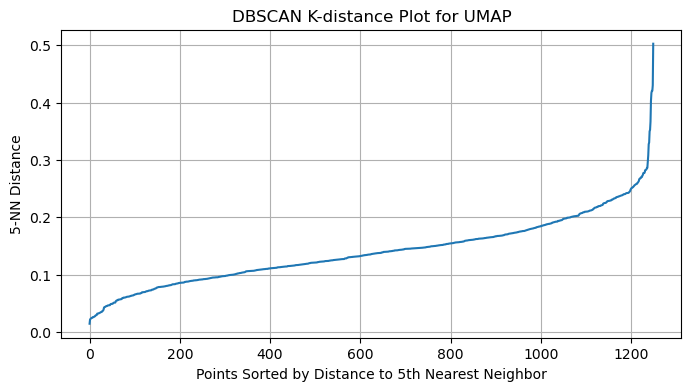

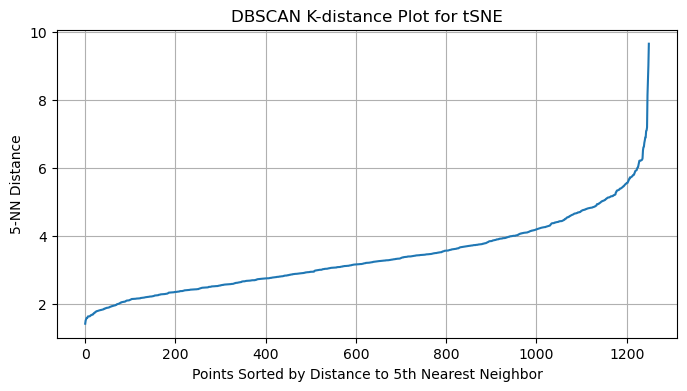

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

dbscan_labels = {}

for name, data in datasets.items():
    neigh = NearestNeighbors(n_neighbors=5)
    nbrs = neigh.fit(data)
    distances, _ = nbrs.kneighbors(data)
    sorted_distances = np.sort(distances[:, 4])

    # Plot the k-distance graph to help estimate eps
    plt.figure(figsize=(8, 4))
    plt.plot(sorted_distances)
    plt.title(f'DBSCAN K-distance Plot for {name}')
    plt.xlabel('Points Sorted by Distance to 5th Nearest Neighbor')
    plt.ylabel('5-NN Distance')
    plt.grid(True)
    plt.show()

    # Use 95th percentile heuristic for eps
    eps = sorted_distances[int(len(sorted_distances) * 0.95)]
    db = DBSCAN(eps=eps, min_samples=5)
    labels = db.fit_predict(data)

    dbscan_labels[name] = labels


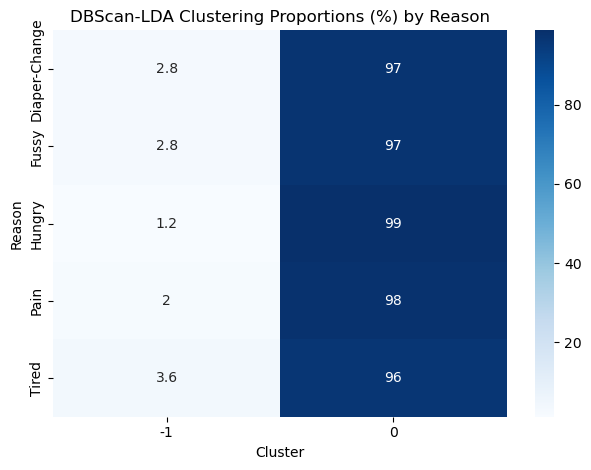

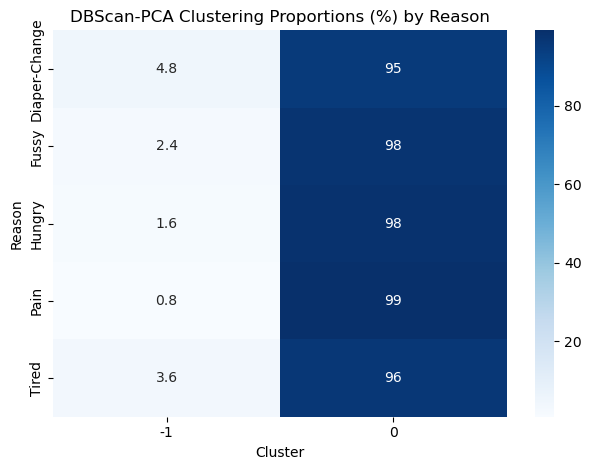

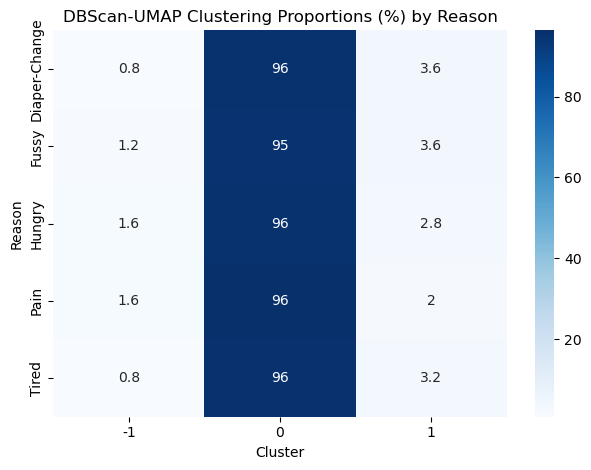

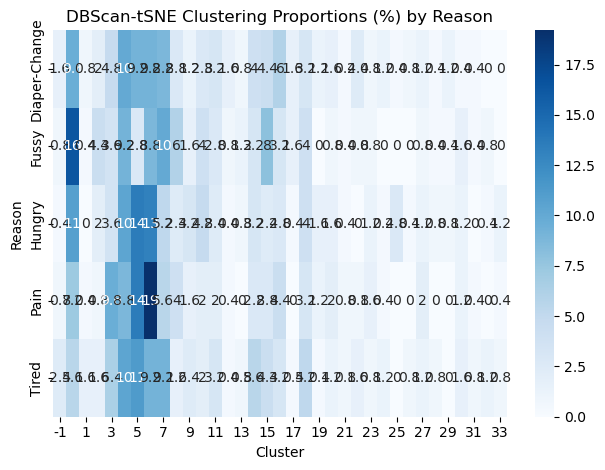

In [ ]:
for name, labels in dbscan_labels.items():
    dbscan_crosstab = pd.crosstab(index=y, columns=labels, normalize='index')
    dbscan_proportion_table = dbscan_crosstab.round(3) * 100
    sns.heatmap(dbscan_proportion_table, annot=True, cmap="Blues")
    plt.title(f"DBScan-{name} Clustering Proportions (%) by Reason")
    plt.xlabel("Cluster")
    plt.ylabel("Reason")
    plt.tight_layout()
    plt.show()